In [ ]:
# ============================================================
# CELL 1 : ENVIRONMENT SETUP
# Deep Learning Lab 3 - CNN using CIFAR-10
# ============================================================

import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    AveragePooling2D,
    Dense,
    Flatten,
    Dropout,
    Input
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# ------------------------------------------------------------
# Create Project Folder Structure
# ------------------------------------------------------------

PROJECT_DIR = "DL_Lab3_CNN"

folders = [
    "Figures",
    "Models",
    "Reports",
    "Predictions"
]

for folder in folders:
    os.makedirs(os.path.join(PROJECT_DIR, folder), exist_ok=True)

print("="*65)
print("Project Directory Created Successfully")
print("="*65)

for folder in folders:
    print("✓", folder)

# ------------------------------------------------------------
# Plot Settings
# ------------------------------------------------------------

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 14

# ------------------------------------------------------------
# Function to Save Figures
# ------------------------------------------------------------

def save_figure(fig_name):
    plt.savefig(
        os.path.join(PROJECT_DIR, "Figures", fig_name + ".eps"),
        format="eps",
        dpi=600,
        bbox_inches="tight"
    )

print("\nAll figures will be saved as:")
print("• EPS format")
print("• 600 DPI")
print("• Times New Roman Font")
print("• Font Size 14")

# ------------------------------------------------------------
# TensorFlow Version
# ------------------------------------------------------------

print("\nTensorFlow Version :", tf.__version__)

Project Directory Created Successfully
✓ Figures
✓ Models
✓ Reports
✓ Predictions

All figures will be saved as:
• EPS format
• 600 DPI
• Times New Roman Font
• Font Size 14

TensorFlow Version : 2.20.0


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 468s 3us/step


CIFAR-10 DATASET INFORMATION
Training Images : (50000, 32, 32, 3)
Training Labels : (50000, 1)
Testing Images  : (10000, 32, 32, 3)
Testing Labels  : (10000, 1)

Image Shape     : (32, 32, 3)
Number of Classes: 10


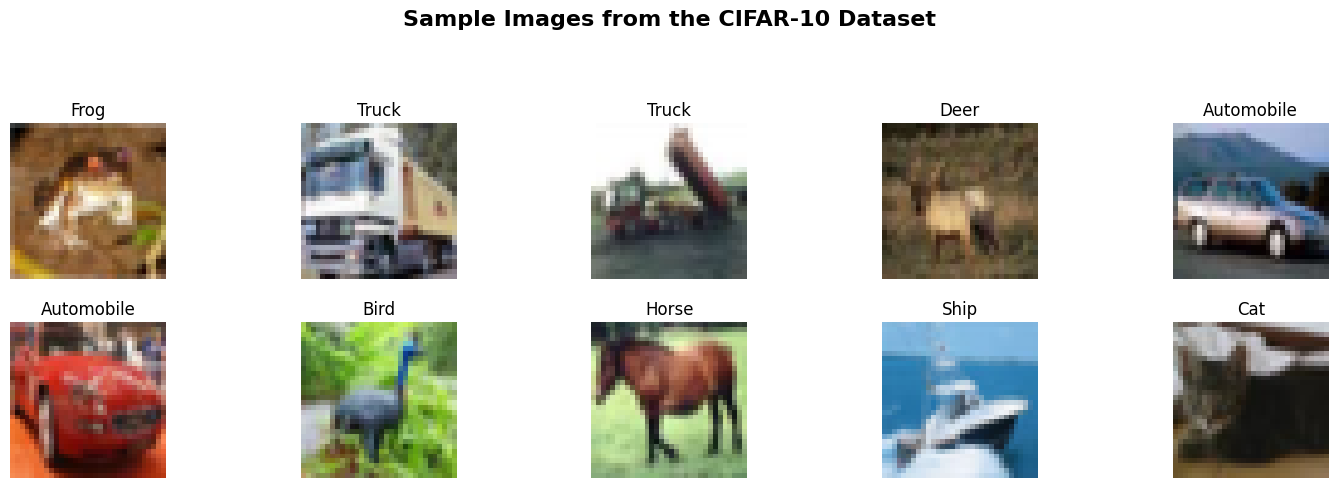


✓ Sample images saved successfully.


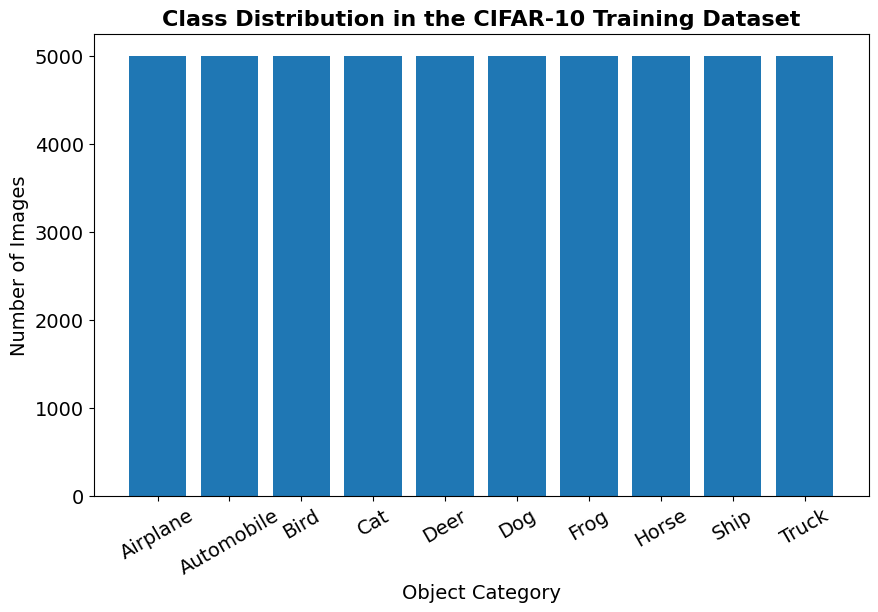

✓ Class distribution plot saved successfully.

Dataset summary saved to Reports folder.


In [ ]:
# ============================================================
# CELL 2 : LOAD AND EXPLORE THE CIFAR-10 DATASET
# ============================================================

# ------------------------------------------------------------
# Load Dataset
# ------------------------------------------------------------

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Class names
class_names = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

print("="*70)
print("CIFAR-10 DATASET INFORMATION")
print("="*70)

print(f"Training Images : {X_train.shape}")
print(f"Training Labels : {y_train.shape}")
print(f"Testing Images  : {X_test.shape}")
print(f"Testing Labels  : {y_test.shape}")

print("\nImage Shape     :", X_train[0].shape)
print("Number of Classes:", len(class_names))

# ------------------------------------------------------------
# Display First 10 Sample Images
# ------------------------------------------------------------

fig = plt.figure(figsize=(15,5))

for i in range(10):

    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[int(y_train[i])], fontsize=12)
    plt.axis("off")

plt.suptitle("Sample Images from the CIFAR-10 Dataset",
             fontsize=16,
             fontweight="bold")

plt.tight_layout(rect=[0,0,1,0.92])

save_figure("sample_images")

plt.show()

print("\n✓ Sample images saved successfully.")

# ------------------------------------------------------------
# Plot Class Distribution
# ------------------------------------------------------------

unique, counts = np.unique(y_train, return_counts=True)

fig = plt.figure(figsize=(10,6))

plt.bar(class_names, counts)

plt.title("Class Distribution in the CIFAR-10 Training Dataset",
          fontsize=16,
          fontweight="bold")

plt.xlabel("Object Category")
plt.ylabel("Number of Images")

plt.xticks(rotation=30)

save_figure("class_distribution")

plt.show()

print("✓ Class distribution plot saved successfully.")

# ------------------------------------------------------------
# Save Dataset Summary
# ------------------------------------------------------------

dataset_summary = pd.DataFrame({
    "Class": class_names,
    "Training Images": counts
})

dataset_summary.to_csv(
    os.path.join(PROJECT_DIR,
                 "Reports",
                 "dataset_summary.csv"),
    index=False
)

print("\nDataset summary saved to Reports folder.")

In [ ]:
# ============================================================
# CELL 3 : DATA PREPROCESSING
# Normalize Images and One-Hot Encode Labels
# ============================================================

print("=" * 70)
print("DATA PREPROCESSING")
print("=" * 70)

# ------------------------------------------------------------
# Normalize Image Pixel Values
# ------------------------------------------------------------

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("✓ Image normalization completed.")

# ------------------------------------------------------------
# One-Hot Encode Labels
# ------------------------------------------------------------

y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

print("✓ One-hot encoding completed.")

# ------------------------------------------------------------
# Display Preprocessing Information
# ------------------------------------------------------------

print("\nTraining Image Shape :", X_train.shape)
print("Testing Image Shape  :", X_test.shape)

print("\nTraining Label Shape :", y_train_cat.shape)
print("Testing Label Shape  :", y_test_cat.shape)

print("\nPixel Value Range")
print("Minimum :", X_train.min())
print("Maximum :", X_train.max())

print("\nImage Data Type :", X_train.dtype)

# ------------------------------------------------------------
# Save Preprocessing Summary
# ------------------------------------------------------------

preprocessing_summary = pd.DataFrame({
    "Property": [
        "Training Image Shape",
        "Testing Image Shape",
        "Training Label Shape",
        "Testing Label Shape",
        "Pixel Minimum",
        "Pixel Maximum",
        "Image Data Type"
    ],
    "Value": [
        str(X_train.shape),
        str(X_test.shape),
        str(y_train_cat.shape),
        str(y_test_cat.shape),
        X_train.min(),
        X_train.max(),
        str(X_train.dtype)
    ]
})

preprocessing_summary.to_csv(
    os.path.join(
        PROJECT_DIR,
        "Reports",
        "preprocessing_summary.csv"
    ),
    index=False
)

print("\n✓ Preprocessing summary saved successfully.")

print("\n" + "=" * 70)
print("CHECKPOINT 3 COMPLETED")
print("=" * 70)

DATA PREPROCESSING
✓ Image normalization completed.
✓ One-hot encoding completed.

Training Image Shape : (50000, 32, 32, 3)
Testing Image Shape  : (10000, 32, 32, 3)

Training Label Shape : (50000, 10)
Testing Label Shape  : (10000, 10)

Pixel Value Range
Minimum : 0.0
Maximum : 1.0

Image Data Type : float32

✓ Preprocessing summary saved successfully.

CHECKPOINT 3 COMPLETED


In [ ]:
# ============================================================
# CELL 4 : TASK 2
# Comparison of Different Convolution Kernel Sizes
# ============================================================

print("=" * 70)
print("TASK 2 : COMPARISON OF DIFFERENT KERNEL SIZES")
print("=" * 70)

# ------------------------------------------------------------
# Select One Sample Image
# ------------------------------------------------------------

sample_image = X_train[0]
sample_input = np.expand_dims(sample_image, axis=0)

# ------------------------------------------------------------
# Function to Build Convolution Model
# ------------------------------------------------------------

def build_conv_model(kernel_size):

    model = Sequential([
        Input(shape=(32, 32, 3)),
        Conv2D(
            filters=8,
            kernel_size=(kernel_size, kernel_size),
            strides=(1, 1),
            padding="valid",
            activation="relu"
        )
    ])

    return model

# ------------------------------------------------------------
# Function to Calculate Output Dimension
# Formula:
# ((N - F + 2P) / S) + 1
# ------------------------------------------------------------

def calculate_output_size(input_size, kernel_size, stride=1, padding=0):

    return ((input_size - kernel_size + (2 * padding)) // stride) + 1

# ------------------------------------------------------------
# Compare Kernel Sizes
# ------------------------------------------------------------

kernel_sizes = [3, 5, 7]

comparison_results = []

for k in kernel_sizes:

    model = build_conv_model(k)

    feature_maps = model.predict(sample_input, verbose=0)

    output_shape = feature_maps.shape

    expected_size = calculate_output_size(
        input_size=32,
        kernel_size=k,
        stride=1,
        padding=0
    )

    comparison_results.append([
        f"{k} × {k}",
        expected_size,
        output_shape[1],
        output_shape[2],
        output_shape[3]
    ])

    print(f"\nKernel Size : {k} × {k}")
    print(f"Expected Feature Map Size : {expected_size} × {expected_size}")
    print(f"TensorFlow Output Shape   : {output_shape}")
    print("-" * 60)

# ------------------------------------------------------------
# Create Comparison Table
# ------------------------------------------------------------

kernel_df = pd.DataFrame(
    comparison_results,
    columns=[
        "Kernel Size",
        "Expected Height",
        "Output Height",
        "Output Width",
        "Number of Feature Maps"
    ]
)

print("\nKernel Comparison Table")
print(kernel_df)

# ------------------------------------------------------------
# Save Results
# ------------------------------------------------------------

kernel_df.to_csv(
    os.path.join(
        PROJECT_DIR,
        "Reports",
        "kernel_comparison.csv"
    ),
    index=False
)

print("\n✓ Kernel comparison table saved successfully.")

print("=" * 70)
print("CHECKPOINT 4 COMPLETED")
print("=" * 70)

TASK 2 : COMPARISON OF DIFFERENT KERNEL SIZES

Kernel Size : 3 × 3
Expected Feature Map Size : 30 × 30
TensorFlow Output Shape   : (1, 30, 30, 8)
------------------------------------------------------------

Kernel Size : 5 × 5
Expected Feature Map Size : 28 × 28
TensorFlow Output Shape   : (1, 28, 28, 8)
------------------------------------------------------------

Kernel Size : 7 × 7
Expected Feature Map Size : 26 × 26
TensorFlow Output Shape   : (1, 26, 26, 8)
------------------------------------------------------------

Kernel Comparison Table
  Kernel Size  Expected Height  Output Height  Output Width  \
0       3 × 3               30             30            30   
1       5 × 5               28             28            28   
2       7 × 7               26             26            26   

   Number of Feature Maps  
0                       8  
1                       8  
2                       8  

✓ Kernel comparison table saved successfully.
CHECKPOINT 4 COMPLETED


In [ ]:
# ============================================================
# CELL 5 : TASK 3
# Comparison of Stride and Padding
# ============================================================

print("=" * 70)
print("TASK 3 : STRIDE AND PADDING COMPARISON")
print("=" * 70)

# ------------------------------------------------------------
# Function to Build CNN Model
# ------------------------------------------------------------

def build_stride_padding_model(stride, padding):

    model = Sequential([
        Input(shape=(32, 32, 3)),
        Conv2D(
            filters=8,
            kernel_size=(3, 3),
            strides=(stride, stride),
            padding=padding,
            activation="relu"
        )
    ])

    return model

# ------------------------------------------------------------
# Function to Calculate Output Dimension
# ------------------------------------------------------------

def calculate_output_size(input_size,
                          kernel_size,
                          stride,
                          padding):

    return ((input_size - kernel_size + (2 * padding)) // stride) + 1


# ------------------------------------------------------------
# Experiment Configurations
# ------------------------------------------------------------

configurations = [

    ("Stride = 1", 1, "valid", 0),
    ("Stride = 2", 2, "valid", 0),
    ("Padding = SAME", 1, "same", None),
    ("Padding = VALID", 1, "valid", 0)

]

results = []

# ------------------------------------------------------------
# Compare Configurations
# ------------------------------------------------------------

for name, stride, padding_type, padding_value in configurations:

    model = build_stride_padding_model(stride, padding_type)

    feature_map = model.predict(sample_input, verbose=0)

    output_shape = feature_map.shape

    # SAME padding keeps output size approximately ceil(N/S)
    if padding_type == "same":

        expected_size = int(np.ceil(32 / stride))

    else:

        expected_size = calculate_output_size(
            input_size=32,
            kernel_size=3,
            stride=stride,
            padding=padding_value
        )

    results.append([
        name,
        stride,
        padding_type.upper(),
        expected_size,
        output_shape[1],
        output_shape[2],
        output_shape[3]
    ])

    print(f"\n{name}")
    print(f"Expected Output Size : {expected_size} × {expected_size}")
    print(f"TensorFlow Output    : {output_shape}")
    print("-" * 60)

# ------------------------------------------------------------
# Create Comparison Table
# ------------------------------------------------------------

stride_padding_df = pd.DataFrame(

    results,

    columns=[
        "Configuration",
        "Stride",
        "Padding",
        "Expected Height",
        "Output Height",
        "Output Width",
        "Feature Maps"
    ]

)

print("\nStride and Padding Comparison\n")
print(stride_padding_df)

# ------------------------------------------------------------
# Save Results
# ------------------------------------------------------------

stride_padding_df.to_csv(

    os.path.join(
        PROJECT_DIR,
        "Reports",
        "stride_padding_comparison.csv"
    ),

    index=False

)

print("\n✓ Comparison table saved successfully.")

print("=" * 70)
print("CHECKPOINT 5 COMPLETED")
print("=" * 70)

TASK 3 : STRIDE AND PADDING COMPARISON

Stride = 1
Expected Output Size : 30 × 30
TensorFlow Output    : (1, 30, 30, 8)
------------------------------------------------------------



Stride = 2
Expected Output Size : 15 × 15
TensorFlow Output    : (1, 15, 15, 8)
------------------------------------------------------------

Padding = SAME
Expected Output Size : 32 × 32
TensorFlow Output    : (1, 32, 32, 8)
------------------------------------------------------------

Padding = VALID
Expected Output Size : 30 × 30
TensorFlow Output    : (1, 30, 30, 8)
------------------------------------------------------------

Stride and Padding Comparison

     Configuration  Stride Padding  Expected Height  Output Height  \
0       Stride = 1       1   VALID               30             30   
1       Stride = 2       2   VALID               15             15   
2   Padding = SAME       1    SAME               32             32   
3  Padding = VALID       1   VALID               30             30   

   Output Width  Feature Maps  
0            30             8  
1            15             8  
2            32             8  
3            30             8  

✓ Comparison table sa

In [ ]:
# ============================================================
# CELL 6 : TASK 6
# CNN Architecture for CIFAR-10 Classification
# ============================================================

print("=" * 70)
print("TASK 6 : CNN MODEL CONSTRUCTION")
print("=" * 70)

# ------------------------------------------------------------
# Hyperparameters
# ------------------------------------------------------------

LEARNING_RATE = 0.001
BATCH_SIZE = 32
EPOCHS = 20
NUM_CLASSES = 10

# ------------------------------------------------------------
# Build CNN Model
# ------------------------------------------------------------

cnn_model = Sequential([

    Input(shape=(32, 32, 3), name="Input"),

    Conv2D(
        filters=16,
        kernel_size=(3, 3),
        activation="relu",
        padding="same",
        name="Conv1"
    ),

    MaxPooling2D(
        pool_size=(2, 2),
        name="MaxPool1"
    ),

    Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu",
        padding="same",
        name="Conv2"
    ),

    MaxPooling2D(
        pool_size=(2, 2),
        name="MaxPool2"
    ),

    Flatten(name="Flatten"),

    Dense(
        128,
        activation="relu",
        name="Dense1"
    ),

    Dropout(
        0.5,
        name="Dropout"
    ),

    Dense(
        NUM_CLASSES,
        activation="softmax",
        name="Output"
    )

])

# ------------------------------------------------------------
# Compile Model
# ------------------------------------------------------------

cnn_model.compile(

    optimizer=Adam(learning_rate=LEARNING_RATE),

    loss="categorical_crossentropy",

    metrics=["accuracy"]

)

# ------------------------------------------------------------
# Display Model Summary
# ------------------------------------------------------------

cnn_model.summary()

# ------------------------------------------------------------
# Save Model Summary
# ------------------------------------------------------------

with open(
    os.path.join(
        PROJECT_DIR,
        "Reports",
        "model_summary.txt"
    ),
    "w"
) as f:

    cnn_model.summary(
        print_fn=lambda x: f.write(x + "\n")
    )

# ------------------------------------------------------------
# Save Hyperparameters
# ------------------------------------------------------------

hyperparameters = pd.DataFrame({

    "Parameter": [

        "Optimizer",
        "Learning Rate",
        "Batch Size",
        "Epochs",
        "Input Shape",
        "Number of Classes"

    ],

    "Value": [

        "Adam",
        LEARNING_RATE,
        BATCH_SIZE,
        EPOCHS,
        "(32,32,3)",
        NUM_CLASSES

    ]

})

hyperparameters.to_csv(

    os.path.join(
        PROJECT_DIR,
        "Reports",
        "hyperparameters.csv"
    ),

    index=False

)

# ------------------------------------------------------------
# Save Untrained Model
# ------------------------------------------------------------

cnn_model.save(

    os.path.join(
        PROJECT_DIR,
        "Models",
        "cnn_model.keras"

    )

)

print("\n✓ CNN model created successfully.")
print("✓ Model summary saved.")
print("✓ Hyperparameters saved.")
print("✓ Untrained model saved.")

print("=" * 70)
print("CHECKPOINT 6 COMPLETED")
print("=" * 70)

TASK 6 : CNN MODEL CONSTRUCTION


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv1 (Conv2D)                  │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool1 (MaxPooling2D)         │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2 (Conv2D)                  │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool2 (MaxPooling2D)         │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense1 (Dense)                  │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 268,650 (1.02 MB)

 Trainable params: 268,650 (1.02 MB)

 Non-trainable params: 0 (0.00 B)


✓ CNN model created successfully.
✓ Model summary saved.
✓ Hyperparameters saved.
✓ Untrained model saved.
CHECKPOINT 6 COMPLETED


In [ ]:
# ============================================================
# CELL 7 : MODEL TRAINING
# Train CNN Model on CIFAR-10
# ============================================================

import time

print("=" * 70)
print("TASK 6 : CNN MODEL TRAINING")
print("=" * 70)

# ------------------------------------------------------------
# Start Training Timer
# ------------------------------------------------------------

start_time = time.time()

# ------------------------------------------------------------
# Train the CNN Model
# ------------------------------------------------------------

history = cnn_model.fit(

    X_train,
    y_train_cat,

    validation_data=(X_test, y_test_cat),

    epochs=EPOCHS,

    batch_size=BATCH_SIZE,

    verbose=1

)

# ------------------------------------------------------------
# End Training Timer
# ------------------------------------------------------------

end_time = time.time()

training_time = end_time - start_time

print(f"\nTraining Time : {training_time:.2f} seconds")

# ------------------------------------------------------------
# Save Trained Model
# ------------------------------------------------------------

cnn_model.save(

    os.path.join(
        PROJECT_DIR,
        "Models",
        "cnn_model_trained.keras"
    )

)

# ------------------------------------------------------------
# Save Training History
# ------------------------------------------------------------

history_df = pd.DataFrame(history.history)

history_df.to_csv(

    os.path.join(
        PROJECT_DIR,
        "Reports",
        "training_history.csv"
    ),

    index=False

)

# ------------------------------------------------------------
# Save Training Summary
# ------------------------------------------------------------

training_summary = pd.DataFrame({

    "Metric": [

        "Training Time (seconds)",
        "Epochs",
        "Batch Size",
        "Final Training Accuracy",
        "Final Validation Accuracy",
        "Final Training Loss",
        "Final Validation Loss"

    ],

    "Value": [

        round(training_time,2),
        EPOCHS,
        BATCH_SIZE,

        round(history.history["accuracy"][-1],4),

        round(history.history["val_accuracy"][-1],4),

        round(history.history["loss"][-1],4),

        round(history.history["val_loss"][-1],4)

    ]

})

training_summary.to_csv(

    os.path.join(
        PROJECT_DIR,
        "Reports",
        "training_summary.csv"
    ),

    index=False

)

# ------------------------------------------------------------
# Display Final Results
# ------------------------------------------------------------

print("\nFinal Training Accuracy   :",
      round(history.history["accuracy"][-1],4))

print("Final Validation Accuracy :",
      round(history.history["val_accuracy"][-1],4))

print("Final Training Loss       :",
      round(history.history["loss"][-1],4))

print("Final Validation Loss     :",
      round(history.history["val_loss"][-1],4))

print("\n✓ Training history saved.")
print("✓ Training summary saved.")
print("✓ Trained model saved.")

print("=" * 70)
print("CHECKPOINT 7 COMPLETED")
print("=" * 70)

TASK 6 : CNN MODEL TRAINING
Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 61s 38ms/step - accuracy: 0.3756 - loss: 1.7054 - val_accuracy: 0.5362 - val_loss: 1.3293
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 36ms/step - accuracy: 0.4971 - loss: 1.3991 - val_accuracy: 0.5856 - val_loss: 1.1739
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 54s 35ms/step - accuracy: 0.5443 - loss: 1.2784 - val_accuracy: 0.6125 - val_loss: 1.0951
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 54s 35ms/step - accuracy: 0.5713 - loss: 1.2048 - val_accuracy: 0.6137 - val_loss: 1.0834
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 54s 35ms/step - accuracy: 0.5960 - loss: 1.1350 - val_accuracy: 0.6444 - val_loss: 1.0075
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 53s 34ms/step - accuracy: 0.6097 - loss: 1.0945 - val_accuracy: 0.6525 - val_loss: 0.9806
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 53s 34ms/step - accuracy: 0.6295 - loss: 1.0448 - val_accuracy: 0.6580 - val_loss: 0.9566
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 34

TRAINING PERFORMANCE VISUALIZATION


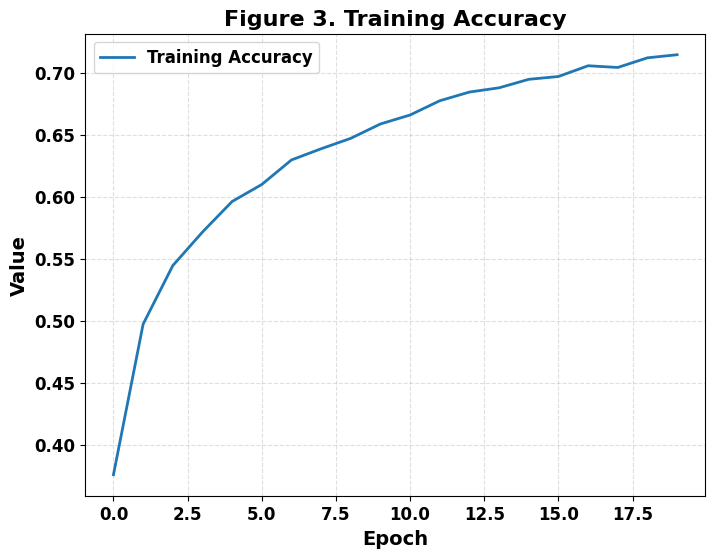

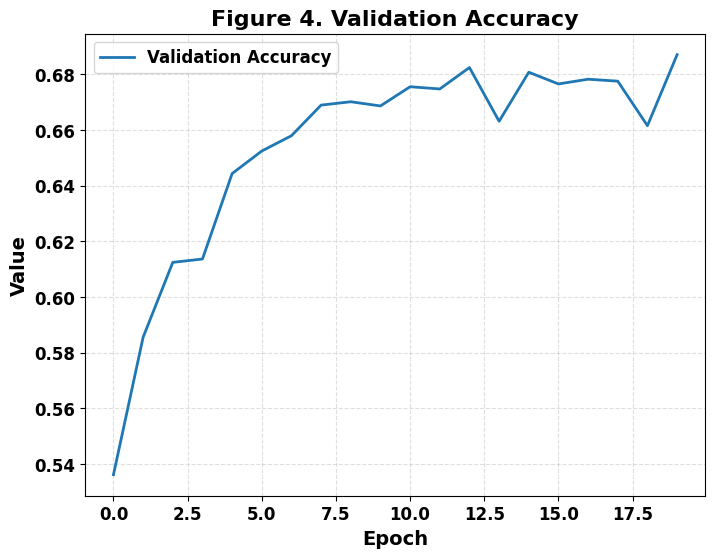

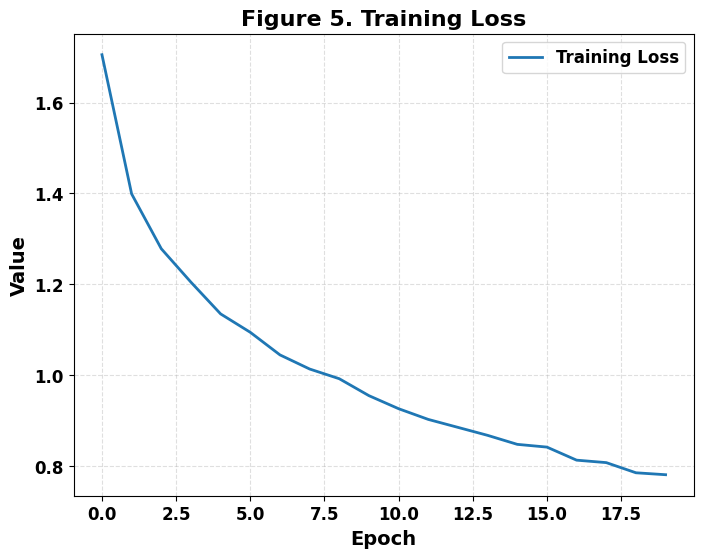

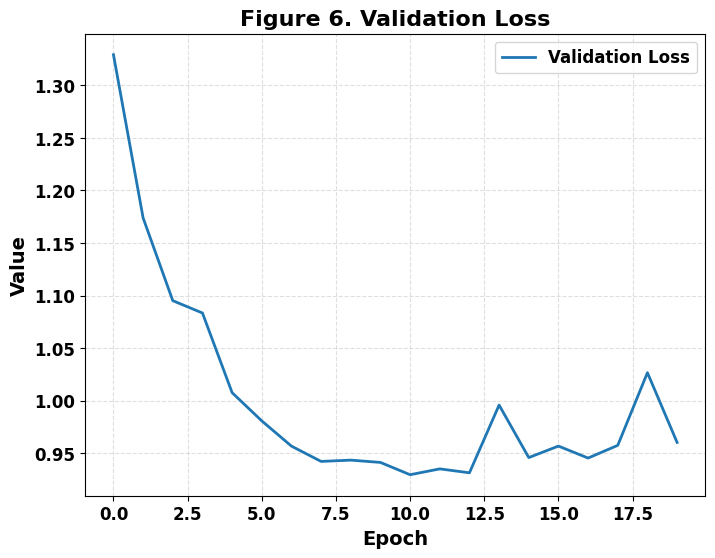


✓ Training accuracy plot saved.
✓ Validation accuracy plot saved.
✓ Training loss plot saved.
✓ Validation loss plot saved.
CHECKPOINT 8 COMPLETED


In [ ]:
# ============================================================
# CELL 8 : TRAINING AND VALIDATION PERFORMANCE PLOTS
# ============================================================

print("=" * 70)
print("TRAINING PERFORMANCE VISUALIZATION")
print("=" * 70)

# ------------------------------------------------------------
# Function to Format Plots
# ------------------------------------------------------------

def format_plot():

    plt.xlabel(
        "Epoch",
        fontsize=14,
        fontweight="bold"
    )

    plt.ylabel(
        "Value",
        fontsize=14,
        fontweight="bold"
    )

    plt.xticks(fontsize=12, fontweight="bold")
    plt.yticks(fontsize=12, fontweight="bold")

    plt.grid(
        linestyle="--",
        alpha=0.4
    )

    plt.legend(
        prop={
            "family": "Times New Roman",
            "size": 12,
            "weight": "bold"
        }
    )

# ============================================================
# Training Accuracy
# ============================================================

plt.figure(figsize=(8,6))

plt.plot(
    history.history["accuracy"],
    linewidth=2,
    label="Training Accuracy"
)

plt.title(
    "Figure 3. Training Accuracy",
    fontsize=16,
    fontweight="bold"
)

format_plot()

save_figure("training_accuracy")

plt.show()

# ============================================================
# Validation Accuracy
# ============================================================

plt.figure(figsize=(8,6))

plt.plot(
    history.history["val_accuracy"],
    linewidth=2,
    label="Validation Accuracy"
)

plt.title(
    "Figure 4. Validation Accuracy",
    fontsize=16,
    fontweight="bold"
)

format_plot()

save_figure("validation_accuracy")

plt.show()

# ============================================================
# Training Loss
# ============================================================

plt.figure(figsize=(8,6))

plt.plot(
    history.history["loss"],
    linewidth=2,
    label="Training Loss"
)

plt.title(
    "Figure 5. Training Loss",
    fontsize=16,
    fontweight="bold"
)

format_plot()

save_figure("training_loss")

plt.show()

# ============================================================
# Validation Loss
# ============================================================

plt.figure(figsize=(8,6))

plt.plot(
    history.history["val_loss"],
    linewidth=2,
    label="Validation Loss"
)

plt.title(
    "Figure 6. Validation Loss",
    fontsize=16,
    fontweight="bold"
)

format_plot()

save_figure("validation_loss")

plt.show()

print("\n✓ Training accuracy plot saved.")
print("✓ Validation accuracy plot saved.")
print("✓ Training loss plot saved.")
print("✓ Validation loss plot saved.")

print("=" * 70)
print("CHECKPOINT 8 COMPLETED")
print("=" * 70)

TASK 4 : FEATURE MAP VISUALIZATION


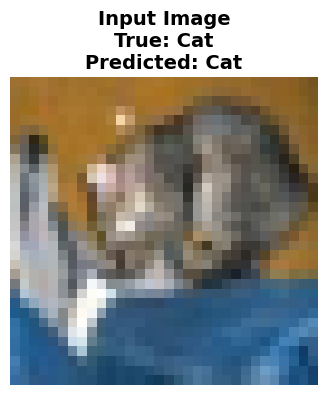

Feature Map Shape : (1, 32, 32, 16)


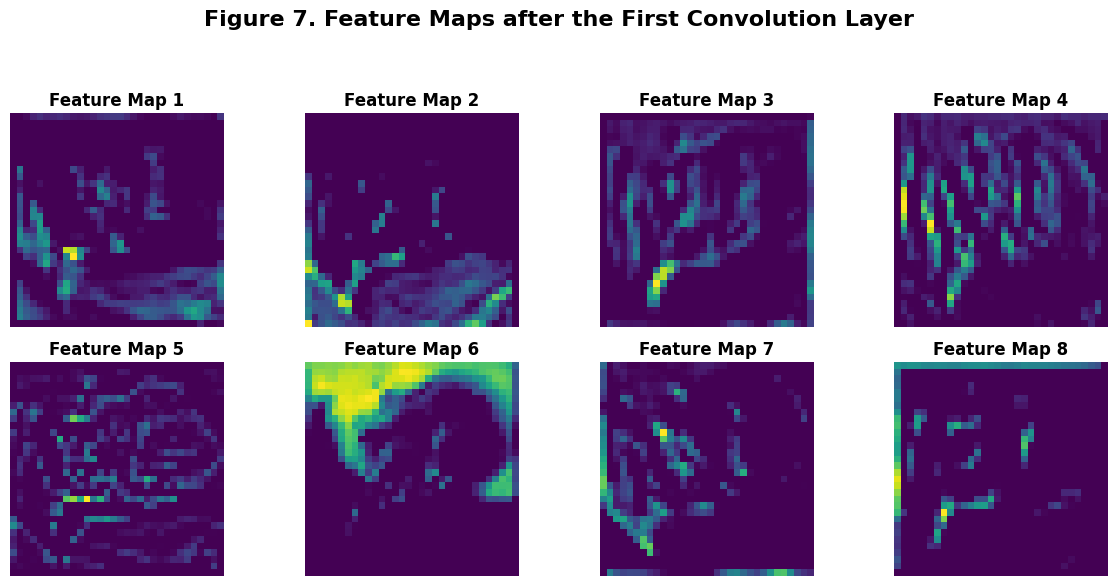


Feature Map Statistics
----------------------------------------
Shape   : (1, 32, 32, 16)
Minimum : 0.0
Maximum : 1.6111
Mean    : 0.0648

✓ Input image saved successfully.
✓ Feature maps generated successfully.
✓ Feature map visualization saved as EPS.
✓ Task 4 completed successfully.
CHECKPOINT 9 COMPLETED


In [ ]:
# ============================================================
# CELL 9 : TASK 4
# Feature Map Visualization after First Convolution Layer
# ============================================================

print("=" * 70)
print("TASK 4 : FEATURE MAP VISUALIZATION")
print("=" * 70)

from tensorflow.keras.models import load_model

# ------------------------------------------------------------
# Load Trained CNN Model
# ------------------------------------------------------------

cnn_model = load_model(
    os.path.join(
        PROJECT_DIR,
        "Models",
        "cnn_model_trained.keras"
    )
)

# ------------------------------------------------------------
# Build Model (Required for Keras 3)
# ------------------------------------------------------------

_ = cnn_model.predict(
    np.zeros((1, 32, 32, 3), dtype=np.float32),
    verbose=0
)

# ------------------------------------------------------------
# Create Feature Extraction Model
# ------------------------------------------------------------

feature_model = tf.keras.Model(
    inputs=cnn_model.inputs,
    outputs=cnn_model.get_layer("Conv1").output
)

# ------------------------------------------------------------
# Select Sample Image
# ------------------------------------------------------------

sample_index = 0

sample_image = X_test[sample_index]
sample_input = np.expand_dims(sample_image, axis=0)

# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------

prediction = cnn_model.predict(sample_input, verbose=0)

predicted_class = class_names[np.argmax(prediction)]
true_class = class_names[int(y_test[sample_index])]

# ------------------------------------------------------------
# Display Original Image
# ------------------------------------------------------------

plt.figure(figsize=(4,4))

plt.imshow(sample_image)

plt.title(
    f"Input Image\nTrue: {true_class}\nPredicted: {predicted_class}",
    fontsize=14,
    fontweight="bold"
)

plt.axis("off")

save_figure("input_image")

plt.show()

# ------------------------------------------------------------
# Generate Feature Maps
# ------------------------------------------------------------

feature_maps = feature_model.predict(
    sample_input,
    verbose=0
)

print("Feature Map Shape :", feature_maps.shape)

# ------------------------------------------------------------
# Display First Eight Feature Maps
# ------------------------------------------------------------

num_maps = min(8, feature_maps.shape[-1])

fig = plt.figure(figsize=(12,6))

for i in range(num_maps):

    plt.subplot(2,4,i+1)

    feature = feature_maps[0, :, :, i]

    # Normalize feature map
    feature = feature - feature.min()

    if feature.max() > 0:
        feature = feature / feature.max()

    plt.imshow(
        feature,
        cmap="viridis",
        interpolation="nearest"
    )

    plt.title(
        f"Feature Map {i+1}",
        fontsize=12,
        fontweight="bold"
    )

    plt.axis("off")

plt.suptitle(
    "Figure 7. Feature Maps after the First Convolution Layer",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(rect=[0,0,1,0.94])

save_figure("feature_maps")

plt.show()

# ------------------------------------------------------------
# Feature Map Statistics
# ------------------------------------------------------------

print("\nFeature Map Statistics")
print("-"*40)

print("Shape   :", feature_maps.shape)
print("Minimum :", round(feature_maps.min(),4))
print("Maximum :", round(feature_maps.max(),4))
print("Mean    :", round(feature_maps.mean(),4))

# ------------------------------------------------------------
# Checkpoint
# ------------------------------------------------------------

print("\n✓ Input image saved successfully.")
print("✓ Feature maps generated successfully.")
print("✓ Feature map visualization saved as EPS.")
print("✓ Task 4 completed successfully.")

print("=" * 70)
print("CHECKPOINT 9 COMPLETED")
print("=" * 70)

In [ ]:
# ============================================================
# CELL 10 : TASK 5
# Max Pooling vs Average Pooling Comparison
# ============================================================

import time

print("=" * 70)
print("TASK 5 : MAX POOLING VS AVERAGE POOLING")
print("=" * 70)

# ------------------------------------------------------------
# Function to Build CNN Model
# ------------------------------------------------------------

def build_pooling_model(pooling_type="max"):

    model = Sequential([

        Input(shape=(32,32,3), name="Input"),

        Conv2D(
            16,
            (3,3),
            padding="same",
            activation="relu",
            name="Conv1"
        ),

        MaxPooling2D((2,2), name="Pool1")
        if pooling_type=="max"
        else AveragePooling2D((2,2), name="Pool1"),

        Conv2D(
            32,
            (3,3),
            padding="same",
            activation="relu",
            name="Conv2"
        ),

        MaxPooling2D((2,2), name="Pool2")
        if pooling_type=="max"
        else AveragePooling2D((2,2), name="Pool2"),

        Flatten(),

        Dense(
            128,
            activation="relu"
        ),

        Dropout(0.5),

        Dense(
            10,
            activation="softmax"
        )

    ])

    model.compile(

        optimizer=Adam(),

        loss="categorical_crossentropy",

        metrics=["accuracy"]

    )

    return model


# ------------------------------------------------------------
# Models
# ------------------------------------------------------------

models = {

    "Max Pooling": build_pooling_model("max"),

    "Average Pooling": build_pooling_model("average")

}

comparison_results = []

model_predictions = {}

trained_models = {}

# ------------------------------------------------------------
# Train Models
# ------------------------------------------------------------

for model_name, model in models.items():

    print("\n" + "="*60)
    print(model_name)
    print("="*60)

    start = time.time()

    history = model.fit(

        X_train,
        y_train_cat,

        validation_data=(X_test,y_test_cat),

        epochs=EPOCHS,

        batch_size=BATCH_SIZE,

        verbose=0

    )

    training_time = time.time()-start

    predictions = model.predict(
        X_test,
        verbose=0
    )

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    accuracy = accuracy_score(
        y_test,
        predicted_labels
    )

    precision = precision_score(
        y_test,
        predicted_labels,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predicted_labels,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predicted_labels,
        average="weighted",
        zero_division=0
    )

    comparison_results.append([

        model_name,

        round(accuracy,4),

        round(precision,4),

        round(recall,4),

        round(f1,4),

        round(training_time,2)

    ])

    model_predictions[model_name] = predicted_labels

    trained_models[model_name] = model

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"Time     : {training_time:.2f} sec")


# ------------------------------------------------------------
# Comparison Table
# ------------------------------------------------------------

comparison_df = pd.DataFrame(

    comparison_results,

    columns=[

        "Pooling Method",

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score",

        "Training Time (s)"

    ]

)

print("\nPooling Comparison\n")

display(comparison_df)

# ------------------------------------------------------------
# Save Results
# ------------------------------------------------------------

comparison_df.to_csv(

    os.path.join(

        PROJECT_DIR,

        "Reports",

        "pooling_comparison.csv"

    ),

    index=False

)

# ------------------------------------------------------------
# Save Both Models
# ------------------------------------------------------------

trained_models["Max Pooling"].save(

    os.path.join(
        PROJECT_DIR,
        "Models",
        "cnn_max_pooling.keras"
    )

)

trained_models["Average Pooling"].save(

    os.path.join(
        PROJECT_DIR,
        "Models",
        "cnn_average_pooling.keras"
    )

)

print("\n✓ Comparison table saved.")
print("✓ Both trained models saved.")

print("="*70)
print("CHECKPOINT 10 COMPLETED")
print("="*70)

TASK 5 : MAX POOLING VS AVERAGE POOLING

Max Pooling
Accuracy : 0.6880
Precision: 0.6900
Recall   : 0.6880
F1 Score : 0.6859
Time     : 1442.83 sec

Average Pooling


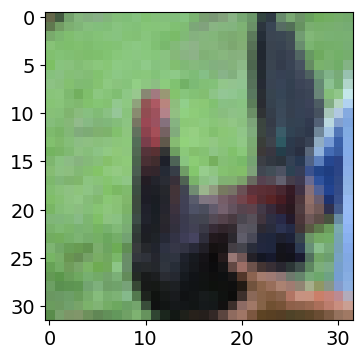

In [ ]:
print("=" * 60)

print("X_train")
print("Shape :", X_train.shape)
print("dtype :", X_train.dtype)
print("Min   :", X_train.min())
print("Max   :", X_train.max())

print()

print("X_test")
print("Shape :", X_test.shape)
print("dtype :", X_test.dtype)
print("Min   :", X_test.min())
print("Max   :", X_test.max())

print()

print("First image statistics")
print("Min :", X_test[0].min())
print("Max :", X_test[0].max())
print("Mean:", X_test[0].mean())

X_train
Shape : (50000, 32, 32, 3)
dtype : float32
Min   : 0.0
Max   : 1.0

X_test
Shape : (10000, 32, 32, 3)
dtype : float32
Min   : 0.0
Max   : 1.0

First image statistics
Min : 0.050980393
Max : 1.0
Mean: 0.42504343


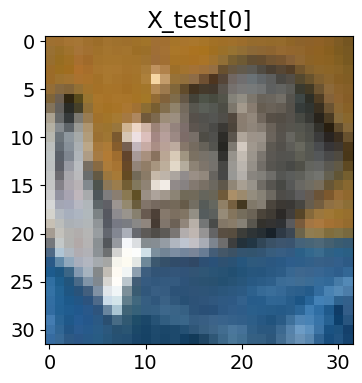

In [ ]:
feature_maps = feature_model.predict(sample_input, verbose=0)

print("Shape :", feature_maps.shape)
print("Minimum :", feature_maps.min())
print("Maximum :", feature_maps.max())
print("Mean :", feature_maps.mean())

Shape : (1, 32, 32, 16)
Minimum : 0.0
Maximum : 1.3727032
Mean : 0.061300468
